# ============================================================
# FASE 4: SIMULAZIONE DEL BUSINESS IMPACT (SHADOW MODE)
# File: 03_business_simulation.ipynb
# ============================================================
#
# STRUTTURA DEL NOTEBOOK:
#   CELLA 1 — Setup: caricamento modello, dati, previsioni corrette
#   CELLA 2 — Parametri economici e funzione di simulazione
#   CELLA 3 — Calcolo dei tre scenari
#   CELLA 4 — Report finanziario sintetico (testo)
#   CELLA 5 — Analisi degli sprechi e delle vendite perse
#   CELLA 6 — Grafico 1: Profitti per scenario (bar chart README)
#   CELLA 7 — Grafico 2: Breakdown costi/ricavi/sprechi
#   CELLA 8 — Analisi per Macro-Categoria
#   CELLA 9 — Stringa riassuntiva pronta per il README.md
# ============================================================

In [1]:
# ============================================================
# CELLA 1 — SETUP: Caricamento modello, dati e previsioni
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import joblib
import os

# ---------- Carica il modello e il fattore di correzione ----------
modello_lgb     = joblib.load('models/modello_lgbm.pkl')
bias_correction = joblib.load('models/bias_correction.pkl')
print(f"✅ Modello caricato  |  Bias correction factor: {bias_correction:.4f}")

# ---------- Carica il dataset processato ----------
df = pd.read_csv('data/processed/dati_modello.csv')

# Ricostruisci le colonne categoriche (necessario dopo il caricamento da CSV)
colonne_categoriche = ['category', 'cuisine', 'center_type', 'Macro_Categoria',
                       'city_code', 'region_code', 'center_id', 'meal_id', 'trimestre']
for col in colonne_categoriche:
    if col in df.columns:
        df[col] = df[col].astype('category')

# ---------- Ricrea lo split temporale identico al Notebook 02 ----------
SETTIMANA_VAL  = 134
SETTIMANA_TEST = 142

df_test = df[df['week'] >= SETTIMANA_TEST].copy()

# Lista features (deve essere identica a quella del Notebook 02)
features = [
    'center_id', 'meal_id',
    'checkout_price', 'base_price', 'Sconto_Valore', 'Sconto_Percentuale',
    'emailer_for_promotion', 'homepage_featured',
    'category', 'cuisine', 'center_type', 'op_area', 'Macro_Categoria',
    'city_code', 'region_code',
    'lag_1w', 'lag_1w_log',
    'lag_2w', 'lag_2w_log',
    'lag_4w', 'lag_4w_log',
    'media_mobile_4w', 'media_mobile_8w', 'std_mobile_4w',
    'week', 'mese_approx', 'settimana_anno', 'trimestre'
]
# Tieni solo le feature presenti nel dataset
features = [f for f in features if f in df_test.columns]

X_test = df_test[features]

# ---------- Genera le previsioni CORRETTE (con bias correction) ----------
pred_log             = modello_lgb.predict(X_test)
pred_reale_raw       = np.expm1(pred_log)
pred_reale_corrected = pred_reale_raw * bias_correction   # ← la correzione che abbiamo calibrato

df_test = df_test.copy()
df_test['Previsioni_LGBM'] = pred_reale_corrected

# ---------- Gestione sicura della colonna lag_1w (baseline) ----------
# Rinomina la colonna se necessario per retrocompatibilità
if 'Ordini_Settimana_Scorsa' in df_test.columns and 'lag_1w' not in df_test.columns:
    df_test['lag_1w'] = df_test['Ordini_Settimana_Scorsa']

mediana_globale = df['num_orders_capped'].median()
df_test['lag_1w'] = df_test['lag_1w'].fillna(mediana_globale)

print(f"\nRighe nel test set:  {len(df_test):,}")
print(f"Settimane:           {df_test['week'].min()} → {df_test['week'].max()}")
print(f"Media ordini reali:  {df_test['num_orders_capped'].mean():.1f}")
print(f"Media previsioni:    {df_test['Previsioni_LGBM'].mean():.1f}")



✅ Modello caricato  |  Bias correction factor: 1.1206

Righe nel test set:  13,113
Settimane:           142 → 145
Media ordini reali:  225.4
Media previsioni:    227.1


In [2]:
# ============================================================
# CELLA 2 — PARAMETRI ECONOMICI REALI (DAL DATASET)
# ============================================================
#
# MIGLIORAMENTO CHIAVE rispetto a valori fissi inventati:
# invece di dire "ogni pasto vale €10 e costa €3", usiamo
# i prezzi REALI presenti nel dataset per ogni piatto.
#
# RICAVO UNITARIO = checkout_price
#   Il prezzo effettivamente pagato dal cliente al momento
#   dell'ordine. Varia per piatto, centro, e settimana
#   (cambia durante le promozioni).
#
# COSTO UNITARIO = base_price × FOOD_COST_PCT
#   Il "food cost" è la percentuale del prezzo base che
#   l'azienda spende in materie prime e lavoro diretto.
#   Il 40% è lo standard del settore ristorazione (regola
#   empirica: se vendi un piatto a €10, ~€4 sono costi
#   variabili di produzione).
#   Usiamo base_price (non checkout_price) perché il costo
#   di produzione non cambia se fai uno sconto al cliente:
#   gli ingredienti costano lo stesso.
#
# COSTO STOCKOUT = margine medio sul validation set
#   Il costo di una vendita persa è il margine che non
#   incassi. Lo calcoliamo come media sul dataset reale
#   invece di un valore fisso.
# ============================================================

FOOD_COST_PCT = 0.40   # 40% food cost — standard ristorazione

df_test['Ricavo_Unitario'] = df_test['checkout_price']
df_test['Costo_Unitario']  = df_test['base_price'] * FOOD_COST_PCT
df_test['Margine_Unitario'] = df_test['Ricavo_Unitario'] - df_test['Costo_Unitario']

# Costo stockout = margine medio (quanto perdi per ogni pasto che non riesci a vendere)
COSTO_STOCKOUT_MEDIO = df_test['Margine_Unitario'].mean()

print("=" * 60)
print("  PARAMETRI ECONOMICI — VALORI REALI DAL DATASET")
print("=" * 60)
print(f"  Food Cost applicato:          {FOOD_COST_PCT*100:.0f}% del prezzo base")
print(f"  Ricavo unitario medio:        € {df_test['Ricavo_Unitario'].mean():.2f}")
print(f"  Costo unitario medio:         € {df_test['Costo_Unitario'].mean():.2f}")
print(f"  Margine unitario medio:       € {df_test['Margine_Unitario'].mean():.2f}")
print(f"  Costo stockout (margine med): € {COSTO_STOCKOUT_MEDIO:.2f}")
print("=" * 60)
print(f"\n  Ricavo min: € {df_test['Ricavo_Unitario'].min():.2f}  "
      f"| max: € {df_test['Ricavo_Unitario'].max():.2f}")
print(f"  Costo min:  € {df_test['Costo_Unitario'].min():.2f}  "
      f"| max: € {df_test['Costo_Unitario'].max():.2f}")
print("\n  ⚠️  DISCLAIMER: food cost al 40% è un'ipotesi di settore.")
print("  I risultati sono simulazioni indicative, non dati reali.")
print("=" * 60)


def simula_scenario(ordini_prodotti, domanda_reale, ricavo_unit, costo_unit):
    """
    Simula un singolo scenario operativo con prezzi per-riga.

    Parametri
    ---------
    ordini_prodotti : array  — quante unità decide di produrre il manager
    domanda_reale   : array  — quante unità vengono effettivamente richieste
    ricavo_unit     : array  — prezzo di vendita per ogni riga (checkout_price)
    costo_unit      : array  — costo di produzione per ogni riga (base_price * 40%)

    Restituisce un DataFrame con colonne finanziarie e operative complete.
    """
    ordini  = np.asarray(ordini_prodotti, dtype=float)
    reale   = np.asarray(domanda_reale,   dtype=float)
    ricavo  = np.asarray(ricavo_unit,     dtype=float)
    costo   = np.asarray(costo_unit,      dtype=float)

    vendite        = np.minimum(ordini, reale)
    spreco_unita   = np.maximum(0.0, ordini - reale)
    stockout_unita = np.maximum(0.0, reale  - ordini)

    ricavi         = vendite        * ricavo
    costi_prod     = ordini         * costo
    # Il costo dello stockout usa il margine specifico di quella riga
    margine_riga   = ricavo - costo
    costo_stockout = stockout_unita * np.maximum(0.0, margine_riga)

    profitto_netto  = ricavi - costi_prod
    profitto_totale = profitto_netto - costo_stockout

    return pd.DataFrame({
        'vendite':         vendite,
        'spreco_unita':    spreco_unita,
        'stockout_unita':  stockout_unita,
        'ricavi':          ricavi,
        'costi_prod':      costi_prod,
        'costo_stockout':  costo_stockout,
        'profitto_netto':  profitto_netto,
        'profitto_totale': profitto_totale,
    })



  PARAMETRI ECONOMICI — VALORI REALI DAL DATASET
  Food Cost applicato:          40% del prezzo base
  Ricavo unitario medio:        € 342.95
  Costo unitario medio:         € 143.45
  Margine unitario medio:       € 199.50
  Costo stockout (margine med): € 199.50

  Ricavo min: € 78.57  | max: € 728.53
  Costo min:  € 38.41  | max: € 346.51

  ⚠️  DISCLAIMER: food cost al 40% è un'ipotesi di settore.
  I risultati sono simulazioni indicative, non dati reali.


In [3]:
# ============================================================
# CELLA 3 — CALCOLO DEI TRE SCENARI
# ============================================================
#
# La differenza rispetto alla versione precedente: la funzione
# ora riceve i vettori di prezzi reali per ogni riga invece
# di usare costanti globali. Ogni piatto viene valutato con
# il suo prezzo effettivo — molto più preciso.
# ============================================================

domanda_reale   = df_test['num_orders_capped'].values
ordini_baseline = np.ceil(df_test['lag_1w'].values)
ordini_modello  = np.ceil(df_test['Previsioni_LGBM'].values)

ricavo_v = df_test['Ricavo_Unitario'].values
costo_v  = df_test['Costo_Unitario'].values

ris_oracolo  = simula_scenario(domanda_reale,   domanda_reale, ricavo_v, costo_v)
ris_baseline = simula_scenario(ordini_baseline, domanda_reale, ricavo_v, costo_v)
ris_modello  = simula_scenario(ordini_modello,  domanda_reale, ricavo_v, costo_v)

for col in ris_oracolo.columns:
    df_test[f'oracolo_{col}']  = ris_oracolo[col].values
    df_test[f'baseline_{col}'] = ris_baseline[col].values
    df_test[f'modello_{col}']  = ris_modello[col].values

print("✅ Simulazione completata con prezzi reali per-riga.")
print(f"   Righe simulate: {len(df_test):,}")


✅ Simulazione completata con prezzi reali per-riga.
   Righe simulate: 13,113


In [4]:
# ============================================================
# CELLA 4 — REPORT FINANZIARIO SINTETICO
# ============================================================

def agg(df_results, prefisso):
    """Somma tutte le colonne di uno scenario."""
    return {col: df_results[f'{prefisso}_{col}'].sum()
            for col in ris_oracolo.columns}

agg_o = agg(df_test, 'oracolo')
agg_b = agg(df_test, 'baseline')
agg_m = agg(df_test, 'modello')

delta_profitto      = agg_m['profitto_totale'] - agg_b['profitto_totale']
delta_spreco_unita  = agg_b['spreco_unita']    - agg_m['spreco_unita']
delta_stockout      = agg_b['stockout_unita']  - agg_m['stockout_unita']
roi_vs_baseline     = delta_profitto / abs(agg_b['profitto_totale']) * 100
gap_vs_oracolo_pct  = (agg_o['profitto_totale'] - agg_m['profitto_totale']) / agg_o['profitto_totale'] * 100

# ============================================================
# CREIAMO LE STRINGHE FORMATTATE PRIMA DEL PRINT
# ============================================================
# Formattiamo i numeri con il separatore delle migliaia e il simbolo Euro
prof_o_str = f"€ {agg_o['profitto_totale']:,.0f}"
prof_m_str = f"€ {agg_m['profitto_totale']:,.0f}"
prof_b_str = f"€ {agg_b['profitto_totale']:,.0f}"

print("\n" + "=" * 60)
print("  💰  REPORT DI BUSINESS — IMPATTO ECONOMICO (Test Set)  💰")
print("=" * 60)
print(f"\n  {'SCENARIO':<35} {'PROFITTO TOTALE':>15}")
print(f"  {'-'*52}")

# Ora possiamo usare semplicemente le variabili preparate, mantenendo l'allineamento a destra (>15)
print(f"  {'Oracolo (domanda perfetta)':.<35} {prof_o_str:>15}")
print(f"  {'Modello LightGBM (con bias correction)':.<35} {prof_m_str:>15}")
print(f"  {'Baseline (settimana scorsa)':.<35} {prof_b_str:>15}")
print(f"\n  {'─'*52}")

print(f"\n  🚀 VALORE AGGIUNTO DAL MODELLO vs BASELINE:")
print(f"     Profitto extra:     € {delta_profitto:>10,.0f}  ({roi_vs_baseline:+.2f}%)")
print(f"     Gap vs Oracolo:     {gap_vs_oracolo_pct:.1f}% di margine ancora recuperabile")

print(f"\n  ♻️  IMPATTO OPERATIVO:")
print(f"     Pasti sprecati in meno:     {delta_spreco_unita:>8,.0f}  unità")
print(f"     Stockout ridotti:           {delta_stockout:>8,.0f}  unità")

print(f"\n  📊 BREAKDOWN COSTI:")
print(f"     Costo spreco  — Baseline:  € {agg_b['costi_prod'] - agg_b['ricavi'] + agg_b['costo_stockout']:>8,.0f}")
print(f"     Costo spreco  — LightGBM:  € {agg_m['costi_prod'] - agg_m['ricavi'] + agg_m['costo_stockout']:>8,.0f}")

print(f"\n  ⚠️  Valori calcolati sul test set ({df_test['week'].nunique()} settimane,")
print(f"     {len(df_test):,} combinazioni centro-piatto).")
print("=" * 60)




  💰  REPORT DI BUSINESS — IMPATTO ECONOMICO (Test Set)  💰

  SCENARIO                            PROFITTO TOTALE
  ----------------------------------------------------
  Oracolo (domanda perfetta).........   € 498,601,847
  Modello LightGBM (con bias correction)   € 310,991,531
  Baseline (settimana scorsa)........   € 264,566,274

  ────────────────────────────────────────────────────

  🚀 VALORE AGGIUNTO DAL MODELLO vs BASELINE:
     Profitto extra:     € 46,425,258  (+17.55%)
     Gap vs Oracolo:     37.6% di margine ancora recuperabile

  ♻️  IMPATTO OPERATIVO:
     Pasti sprecati in meno:      148,096  unità
     Stockout ridotti:             78,500  unità

  📊 BREAKDOWN COSTI:
     Costo spreco  — Baseline:  € -264,566,274
     Costo spreco  — LightGBM:  € -310,991,531

  ⚠️  Valori calcolati sul test set (4 settimane,
     13,113 combinazioni centro-piatto).


In [5]:
# ============================================================
# CELLA 5 — ANALISI SPRECHI E VENDITE PERSE PER SETTIMANA
# ============================================================

weekly = df_test.groupby('week').agg(
    oracolo_profitto  = ('oracolo_profitto_totale',  'sum'),
    baseline_profitto = ('baseline_profitto_totale', 'sum'),
    modello_profitto  = ('modello_profitto_totale',  'sum'),
    baseline_spreco   = ('baseline_spreco_unita',    'sum'),
    modello_spreco    = ('modello_spreco_unita',     'sum'),
    baseline_stockout = ('baseline_stockout_unita',  'sum'),
    modello_stockout  = ('modello_stockout_unita',   'sum'),
    domanda_media     = ('num_orders_capped',         'mean'),
).reset_index()

print("\n📅 DETTAGLIO SETTIMANALE")
print("─" * 80)
print(f"  {'Week':>5}  {'Profitto Base':>14}  {'Profitto LGBM':>14}  "
      f"{'Delta':>10}  {'Spreco↓':>9}  {'Stockout↓':>10}")
print("─" * 80)
for _, r in weekly.iterrows():
    delta = r['modello_profitto'] - r['baseline_profitto']
    s_delta = r['baseline_spreco'] - r['modello_spreco']
    k_delta = r['baseline_stockout'] - r['modello_stockout']
    segno = "✅" if delta >= 0 else "❌"
    print(f"  {int(r['week']):>5}  {r['baseline_profitto']:>13,.0f}€  "
          f"{r['modello_profitto']:>13,.0f}€  "
          f"{delta:>+10,.0f}€  {s_delta:>+8,.0f}  {k_delta:>+9,.0f}  {segno}")
print("─" * 80)




📅 DETTAGLIO SETTIMANALE
────────────────────────────────────────────────────────────────────────────────
   Week   Profitto Base   Profitto LGBM       Delta    Spreco↓   Stockout↓
────────────────────────────────────────────────────────────────────────────────
    142     80,503,370€     85,537,257€  +5,033,888€   +30,226     +2,250  ✅
    143     53,363,511€     77,786,018€  +24,422,507€   +69,102    +31,224  ✅
    144     70,879,598€     77,960,825€  +7,081,227€   -10,389    +43,721  ✅
    145     59,819,795€     69,707,431€  +9,887,636€   +59,157     +1,305  ✅
────────────────────────────────────────────────────────────────────────────────


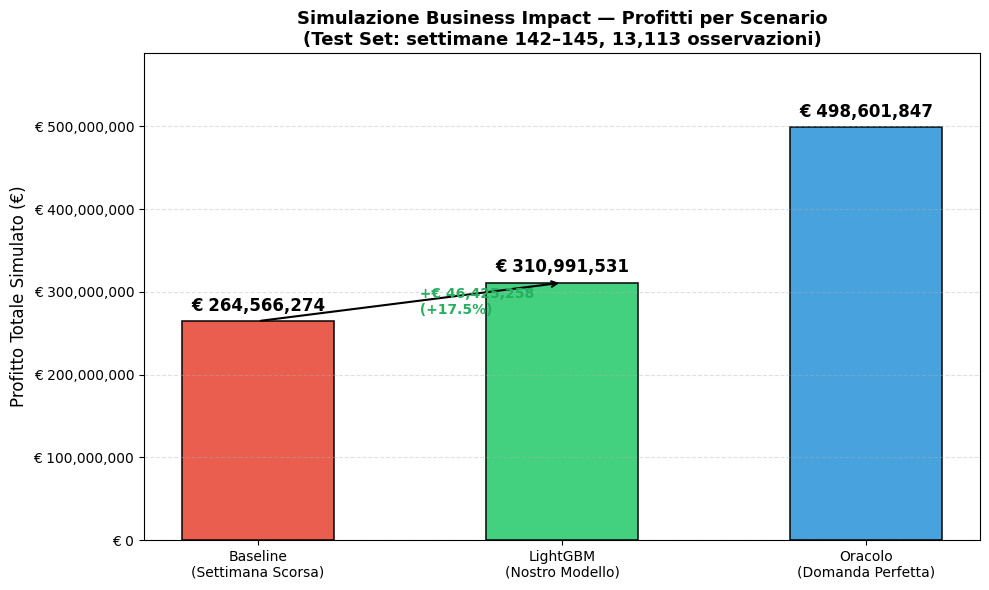

✅ Grafico salvato in img/business_impact.png


In [6]:
# ============================================================
# CELLA 6 — GRAFICO 1: Profitti per scenario (per il README)
# ============================================================

os.makedirs('img', exist_ok=True)

scenari   = ['Baseline\n(Settimana Scorsa)', 'LightGBM\n(Nostro Modello)', 'Oracolo\n(Domanda Perfetta)']
profitti  = [agg_b['profitto_totale'], agg_m['profitto_totale'], agg_o['profitto_totale']]
colori    = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(scenari, profitti, color=colori, edgecolor='black', linewidth=1.2, alpha=0.9, width=0.5)

# Etichette in euro sopra ogni barra
for bar, val in zip(bars, profitti):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + max(profitti) * 0.015,
            f'€ {val:,.0f}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# Freccia e annotazione "valore aggiunto"
ax.annotate('',
    xy=(1, agg_m['profitto_totale']),
    xytext=(0, agg_b['profitto_totale']),
    arrowprops=dict(arrowstyle='->', color='black', lw=1.5,
                    connectionstyle='arc3,rad=0.0'))
ax.text(0.5, (agg_b['profitto_totale'] + agg_m['profitto_totale']) / 2,
        f'  +€ {delta_profitto:,.0f}\n  ({roi_vs_baseline:+.1f}%)',
        ha='left', va='center', fontsize=10, color='#27ae60', fontweight='bold')

ax.set_ylabel('Profitto Totale Simulato (€)', fontsize=12)
ax.set_title('Simulazione Business Impact — Profitti per Scenario\n'
             f'(Test Set: settimane {df_test["week"].min()}–{df_test["week"].max()}, '
             f'{len(df_test):,} osservazioni)',
             fontsize=13, fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€ {x:,.0f}'))
ax.set_ylim(0, max(profitti) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('img/business_impact.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato in img/business_impact.png")


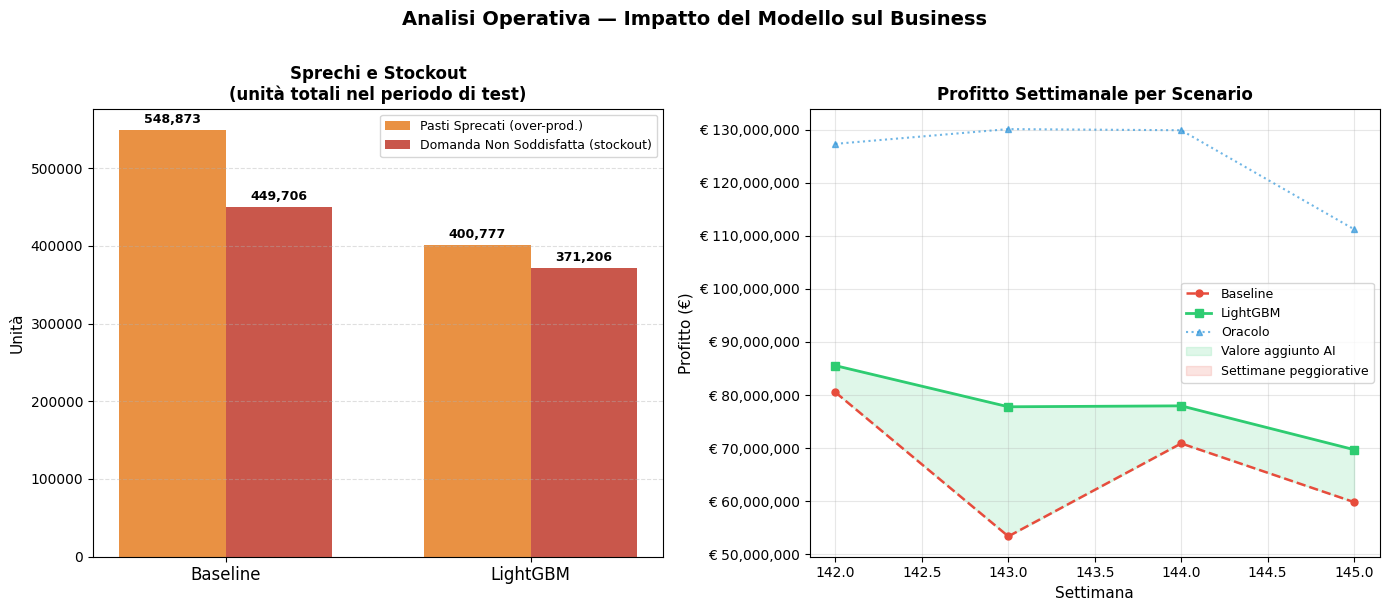

✅ Grafico salvato in img/business_detail.png


In [7]:
# ============================================================
# CELLA 7 — GRAFICO 2: Breakdown costi/sprechi/stockout
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Pannello sinistro: Spreco (unità prodotte e non vendute) ---
ax1 = axes[0]
categorie_confronto = ['Baseline', 'LightGBM']
val_spreco    = [agg_b['spreco_unita'],   agg_m['spreco_unita']]
val_stockout  = [agg_b['stockout_unita'], agg_m['stockout_unita']]

x = np.arange(len(categorie_confronto))
width = 0.35
b1 = ax1.bar(x - width/2, val_spreco,   width, label='Pasti Sprecati (over-prod.)', color='#e67e22', alpha=0.85)
b2 = ax1.bar(x + width/2, val_stockout, width, label='Domanda Non Soddisfatta (stockout)', color='#c0392b', alpha=0.85)

for b in list(b1) + list(b2):
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + max(val_spreco+val_stockout)*0.01,
             f'{b.get_height():,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax1.set_xticks(x)
ax1.set_xticklabels(categorie_confronto, fontsize=12)
ax1.set_ylabel('Unità', fontsize=11)
ax1.set_title('Sprechi e Stockout\n(unità totali nel periodo di test)', fontsize=12, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# --- Pannello destro: Evoluzione settimanale del profitto ---
ax2 = axes[1]
ax2.plot(weekly['week'], weekly['baseline_profitto'], 'o--',
         color='#e74c3c', label='Baseline', linewidth=1.8, markersize=5)
ax2.plot(weekly['week'], weekly['modello_profitto'],  's-',
         color='#2ecc71', label='LightGBM', linewidth=2.0, markersize=6)
ax2.plot(weekly['week'], weekly['oracolo_profitto'],  '^:',
         color='#3498db', label='Oracolo',  linewidth=1.5, markersize=5, alpha=0.7)

ax2.fill_between(weekly['week'],
                 weekly['baseline_profitto'],
                 weekly['modello_profitto'],
                 where=weekly['modello_profitto'] >= weekly['baseline_profitto'],
                 alpha=0.15, color='#2ecc71', label='Valore aggiunto AI')
ax2.fill_between(weekly['week'],
                 weekly['baseline_profitto'],
                 weekly['modello_profitto'],
                 where=weekly['modello_profitto'] < weekly['baseline_profitto'],
                 alpha=0.15, color='#e74c3c', label='Settimane peggiorative')

ax2.set_xlabel('Settimana', fontsize=11)
ax2.set_ylabel('Profitto (€)', fontsize=11)
ax2.set_title('Profitto Settimanale per Scenario', fontsize=12, fontweight='bold')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'€ {x:,.0f}'))
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.suptitle('Analisi Operativa — Impatto del Modello sul Business',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('img/business_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Grafico salvato in img/business_detail.png")




📊 ANALISI PER MACRO-CATEGORIA
────────────────────────────────────────────────────────────────────────────────────────
  Categoria                   Base Prof.   LGBM Prof.    Delta €      Δ%   Spreco↓   € medio
────────────────────────────────────────────────────────────────────────────────────────
  Piatti_Principali          62,835,135€  78,202,733€  +15,367,598  +24.5%  +14,706   486.61€  ✅
  Pasti_Leggeri_e_Antipasti  28,335,057€  39,261,763€  +10,926,706  +38.6%  -12,677   279.60€  ✅
  Fast_Food                  78,392,912€  87,524,455€  +9,131,544  +11.6%  +123,831   412.72€  ✅
  Bevande_e_Extra            80,098,716€  86,699,422€  +6,600,706   +8.2%  +14,597   219.71€  ✅
  Snack_e_Dolci              14,904,454€  19,303,158€  +4,398,703  +29.5%   +7,639   373.11€  ✅
────────────────────────────────────────────────────────────────────────────────────────


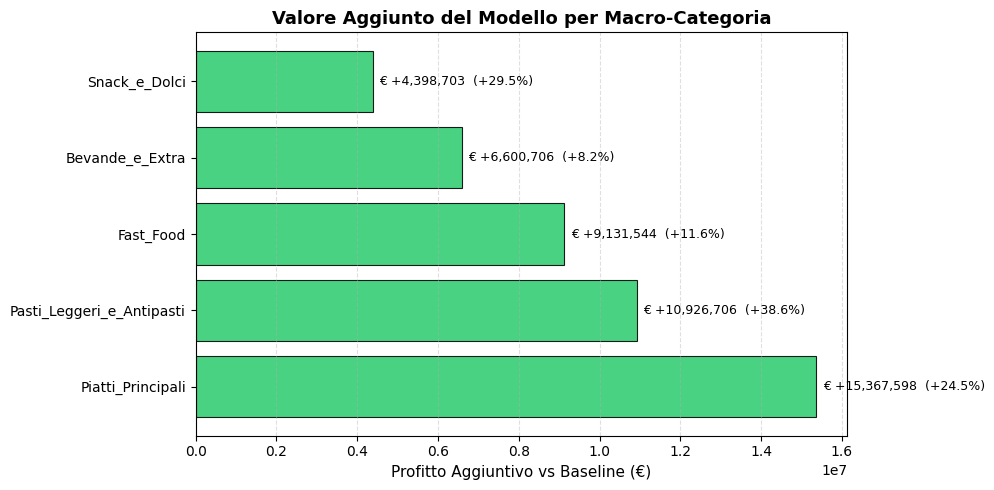

✅ Grafico salvato in img/business_by_category.png


In [8]:
# ============================================================
# CELLA 8 — ANALISI PER MACRO-CATEGORIA (invariata)
# ============================================================

if 'Macro_Categoria' in df_test.columns:

    cat_agg = df_test.groupby('Macro_Categoria', observed=True).agg(
        baseline_profitto  = ('baseline_profitto_totale', 'sum'),
        modello_profitto   = ('modello_profitto_totale',  'sum'),
        baseline_spreco    = ('baseline_spreco_unita',    'sum'),
        modello_spreco     = ('modello_spreco_unita',     'sum'),
        n_righe            = ('num_orders_capped',        'count'),
        domanda_media      = ('num_orders_capped',        'mean'),
        ricavo_medio       = ('Ricavo_Unitario',          'mean'),   # ← extra info sul prezzo
    ).reset_index()

    cat_agg['delta_profitto']    = cat_agg['modello_profitto']  - cat_agg['baseline_profitto']
    cat_agg['delta_spreco']      = cat_agg['baseline_spreco']   - cat_agg['modello_spreco']
    cat_agg['miglioramento_pct'] = cat_agg['delta_profitto'] / cat_agg['baseline_profitto'].abs() * 100
    cat_agg = cat_agg.sort_values('delta_profitto', ascending=False)

    print("\n📊 ANALISI PER MACRO-CATEGORIA")
    print("─" * 88)
    print(f"  {'Categoria':<25}  {'Base Prof.':>11}  {'LGBM Prof.':>11}  "
          f"{'Delta €':>9}  {'Δ%':>6}  {'Spreco↓':>8}  {'€ medio':>8}")
    print("─" * 88)
    for _, r in cat_agg.iterrows():
        segno = "✅" if r['delta_profitto'] >= 0 else "❌"
        print(f"  {str(r['Macro_Categoria']):<25}  "
              f"{r['baseline_profitto']:>10,.0f}€  "
              f"{r['modello_profitto']:>10,.0f}€  "
              f"{r['delta_profitto']:>+9,.0f}  "
              f"{r['miglioramento_pct']:>+5.1f}%  "
              f"{r['delta_spreco']:>+7,.0f}  "
              f"{r['ricavo_medio']:>7.2f}€  {segno}")
    print("─" * 88)

    fig, ax = plt.subplots(figsize=(10, 5))
    colori_delta = ['#2ecc71' if v >= 0 else '#e74c3c' for v in cat_agg['delta_profitto']]
    ax.barh(cat_agg['Macro_Categoria'].astype(str),
            cat_agg['delta_profitto'],
            color=colori_delta, edgecolor='black', linewidth=0.8, alpha=0.88)
    ax.axvline(0, color='black', linewidth=1.2)
    for i, (val, row) in enumerate(zip(cat_agg['delta_profitto'], cat_agg.itertuples())):
        offset = max(cat_agg['delta_profitto'].abs()) * 0.01
        ax.text(val + (offset if val >= 0 else -offset),
                i, f'€ {val:+,.0f}  ({row.miglioramento_pct:+.1f}%)',
                va='center', ha='left' if val >= 0 else 'right', fontsize=9)
    ax.set_xlabel('Profitto Aggiuntivo vs Baseline (€)', fontsize=11)
    ax.set_title('Valore Aggiunto del Modello per Macro-Categoria', fontsize=13, fontweight='bold')
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    plt.tight_layout()
    plt.savefig('img/business_by_category.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Grafico salvato in img/business_by_category.png")
else:
    print("ℹ️  Colonna Macro_Categoria non trovata, analisi per categoria saltata.")

In [10]:

# ============================================================
# CELLA 9 — STRINGA README PRONTA ALL'USO
# ============================================================
# Copia e incolla questo testo nel tuo README.md su GitHub
# ============================================================

n_settimane = df_test['week'].nunique()
n_obs       = len(df_test)

readme_text = f"""
## 📊 Risultati della Simulazione di Business (Fase 4)

> **Metodologia economica**: ricavo = `checkout_price` (prezzo reale del dataset),
> costo = `base_price × {FOOD_COST_PCT*100:.0f}%` (food cost standard ristorazione).
> Parametri dichiarati come ipotesi di simulazione, non dati aziendali reali.

Applicando il modello al test set ({n_settimane} settimane, {n_obs:,} osservazioni centro-piatto),
la simulazione in **Shadow Mode** confronta tre scenari:

| Scenario | Profitto Simulato | vs Baseline |
|---|---|---|
| 🔵 Oracolo (domanda perfetta) | € {agg_o['profitto_totale']:,.0f} | +{(agg_o['profitto_totale']-agg_b['profitto_totale'])/abs(agg_b['profitto_totale'])*100:.1f}% |
| 🟢 **LightGBM (nostro modello)** | **€ {agg_m['profitto_totale']:,.0f}** | **{roi_vs_baseline:+.1f}%** |
| 🔴 Baseline (settimana scorsa) | € {agg_b['profitto_totale']:,.0f} | — |

**Il modello AI ha generato € {delta_profitto:,.0f} di profitto aggiuntivo** rispetto al metodo tradizionale,
riducendo i pasti sprecati di **{delta_spreco_unita:,.0f} unità** e gli stockout di **{delta_stockout:,.0f} unità**.

Rimane un gap del **{gap_vs_oracolo_pct:.1f}%** rispetto all'oracolo teorico — margine di miglioramento
raggiungibile con feature più ricche (es. dati LLM sulle ricette, festività locali).

![Business Impact](img/business_impact.png)
"""

print("\n" + "─" * 60)
print("  📋  TESTO README.md — copia e incolla su GitHub:")
print("─" * 60)
print(readme_text)

# Salva su file per comodità
with open('img/README_fase4_snippet.md', 'w', encoding='utf-8') as f:
    f.write(readme_text)
print("✅ Snippet README salvato in img/README_fase4_snippet.md")



────────────────────────────────────────────────────────────
  📋  TESTO README.md — copia e incolla su GitHub:
────────────────────────────────────────────────────────────

## 📊 Risultati della Simulazione di Business (Fase 4)

> **Metodologia economica**: ricavo = `checkout_price` (prezzo reale del dataset),
> costo = `base_price × 40%` (food cost standard ristorazione).
> Parametri dichiarati come ipotesi di simulazione, non dati aziendali reali.

Applicando il modello al test set (4 settimane, 13,113 osservazioni centro-piatto),
la simulazione in **Shadow Mode** confronta tre scenari:

| Scenario | Profitto Simulato | vs Baseline |
|---|---|---|
| 🔵 Oracolo (domanda perfetta) | € 498,601,847 | +88.5% |
| 🟢 **LightGBM (nostro modello)** | **€ 310,991,531** | **+17.5%** |
| 🔴 Baseline (settimana scorsa) | € 264,566,274 | — |

**Il modello AI ha generato € 46,425,258 di profitto aggiuntivo** rispetto al metodo tradizionale,
riducendo i pasti sprecati di **148,096 unità** e gli stockou